In [8]:
import matplotlib.pyplot as plt
import numpy as np
import sys, torch, matplotlib
from sbi.utils import MultipleIndependent
from torch.distributions import Uniform
from torch import nn
from sbi import utils as utils
from sbi.analysis import pairplot
from sbi.inference import NPE
import scipy.stats as st
import os, pickle

from pathlib import Path
PROJECT_DIR = Path.cwd().parent  # notebooks/ -> repository root
sys.path.insert(0, str(PROJECT_DIR))
from scripts.python.config import (
    DATA_DIR, RESULTS_DIR, ATLAS_LUT, FMRI_DIR, BIFURCATION_DIR,
    TRAINED_MODELS_DIR, SUBJECT, connectome, require,
)
from sbi.neural_nets import posterior_nn

In [9]:
results_path = RESULTS_DIR / 'sbi_data'
atlas_LUT = ATLAS_LUT
lut_aseg  = np.genfromtxt(atlas_LUT, usecols=0, dtype=int)[1:101]
lut_names = np.genfromtxt(atlas_LUT, usecols=1, dtype=str)[1:101]
names = ['_'.join(name.split('_')[1:3]) for name in lut_names]
names_idx = sorted([names.index(name) for name in set(names)])

In [3]:
X = []
Y = []
SEEDS = [f"{int(seed)}" for seed in np.arange((400))]
for seed in SEEDS:
    js = np.load(f"{results_path}/mpr/params/params_mpr_homogeneous_seed{seed}_sub-003.npz")['js'][:,0]
    etas = np.load(f"{results_path}/mpr/params/params_mpr_homogeneous_seed{seed}_sub-003.npz")['etas'][:,0]
    # load only features 5 and 6 corresponding to skewness of FCD and average number of zero crossings
    feats = np.load(f"{results_path}/mpr/feats/feat_mpr_seed{seed}.npz")['bold'][:,[5,6]]
    X.append(np.c_[js, etas, feats])


In [14]:
np.random.seed(42)
torch.manual_seed(42)
X = np.vstack(X)
print(X.shape)
# Check for nans and delete features that are empty and datapoints where at least one feature is nan
to_del = np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[0][np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[1]==X.shape[0]] # del empty features
print(to_del)
X = np.delete(X, to_del, 1)
print(X.shape)
X = np.delete(X, np.unique(np.argwhere(np.isnan(X))[:,0]), 0) # delete datapoints where at least one feature is nan
print(X.shape)

(32000, 4)
[]
(32000, 4)
(30462, 4)


In [15]:
# Randomly remove 500 datapoints to use as GT for the SBI inference
to_remove = np.random.choice(X.shape[0], 500, replace=False)
GT_mpr = X[to_remove]
X = np.delete(X, to_remove, 0)
np.random.shuffle(X)
print(GT_mpr.shape, X.shape)

(500, 4) (29962, 4)


In [16]:
prior = MultipleIndependent(
    [Uniform(low=torch.tensor([8.]), high=torch.tensor([20.]))]*1+[Uniform(low=torch.tensor([-6.]), high=torch.tensor([-2.5]))]*1
)

In [81]:
x = torch.from_numpy(X[:,2:].astype('float32'))
theta = torch.from_numpy(X[:,:2].astype('float32'))

In [82]:
x.shape, theta.shape

(torch.Size([29962, 2]), torch.Size([29962, 2]))

In [83]:
maf = posterior_nn(
    model="maf", z_score_theta='independent', z_score_x='independent', embedding_net=nn.Identity(), num_transforms=10, hidden_features=50
)
inference = NPE(prior=prior, density_estimator=maf, device='cpu')
inference.append_simulations(theta, x)
density_estimator = inference.train(training_batch_size=200)
posterior = inference.build_posterior(density_estimator)

/Users/martinbreyton/INS_Code/data-driven_whole-brain/env/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 189 epochs.

In [84]:
with open('artifacts/posterior_mpr_empirical.pkl', 'wb') as f:
    pickle.dump(posterior, f)

  0%|          | 0/10000 [00:00<?, ?it/s]

10189it [00:00, 76518.00it/s]                          


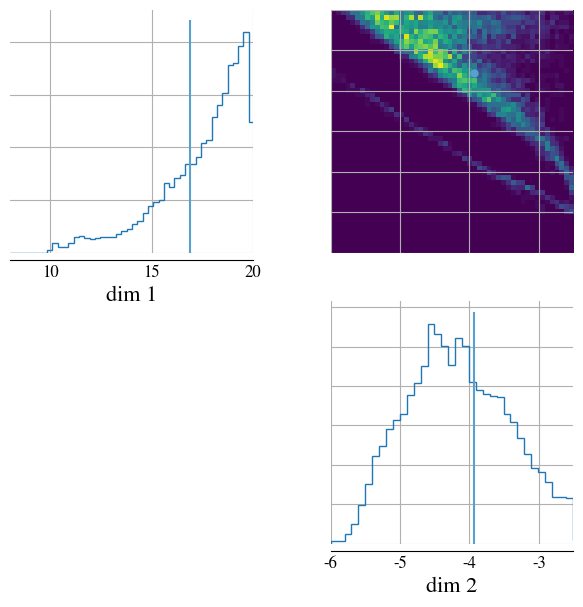

In [86]:
i = 4
samples = posterior.sample((10000,), x=GT_mpr[i,2:].astype('float32'))
limits = [[8, 20]]+[[-6,-2.5]]
_ = pairplot(
    samples, figsize=(6, 6),
    limits=limits,
    points=GT_mpr[i:i+1,:2]
)

In [88]:
X = []
SEEDS = [f"{int(seed)}" for seed in np.arange(1200)]
for seed in SEEDS:
    g = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['gs'].squeeze()
    js = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['js'].squeeze()[:,0]
    etas = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['etas'].squeeze()[:,0]
    ps = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['ps'].squeeze()[:,0]
    feats = np.load(f"{results_path}/mlp/feats/feat_mlp_qif_internal_seed{seed}.npz")['bold'][:,[5,6]]
    X.append(np.c_[js, etas, ps, feats])

In [21]:
np.random.seed(0)
torch.manual_seed(0)
X = np.vstack(X)
to_del = np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[0][np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[1]==X.shape[0]]
print(to_del)
X = np.delete(X, to_del, 1)
print(X.shape)
X = np.delete(X, np.unique(np.argwhere(np.isnan(X))[:,0]), 0) # delete datapoints where at least one feature is nan
print(X.shape)
to_remove = np.random.choice(X.shape[0], 500, replace=False)
GT_mlp = X[to_remove]
GT_mlp.shape, X.shape
X = np.delete(X, to_remove, 0)
np.random.shuffle(X)
X.shape
prior = MultipleIndependent(
    [Uniform(low=torch.tensor([8.]), high=torch.tensor([20.]))]*1+[Uniform(low=torch.tensor([-6.]), high=torch.tensor([-2.5]))]+[Uniform(low=torch.tensor([.6]), high=torch.tensor([1.]))]
)
x = torch.from_numpy(X[:,3:].astype('float32'))
theta = torch.from_numpy(X[:,:3].astype('float32'))

[]
(29962, 4)
(29962, 4)


In [90]:
from sbi.neural_nets import posterior_nn
maf = posterior_nn(
    model="maf", z_score_theta='independent', z_score_x='independent', embedding_net=nn.Identity(), num_transforms=10, hidden_features=50
)
inference = NPE(prior=prior, density_estimator=maf, device='cpu')
inference.append_simulations(theta, x)
density_estimator = inference.train(training_batch_size=200)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 140 epochs.

In [91]:
with open('artifacts/posterior_mlp_qif_empirical.pkl', 'wb') as f:
    pickle.dump(posterior, f)

10147it [00:00, 85639.38it/s]                          


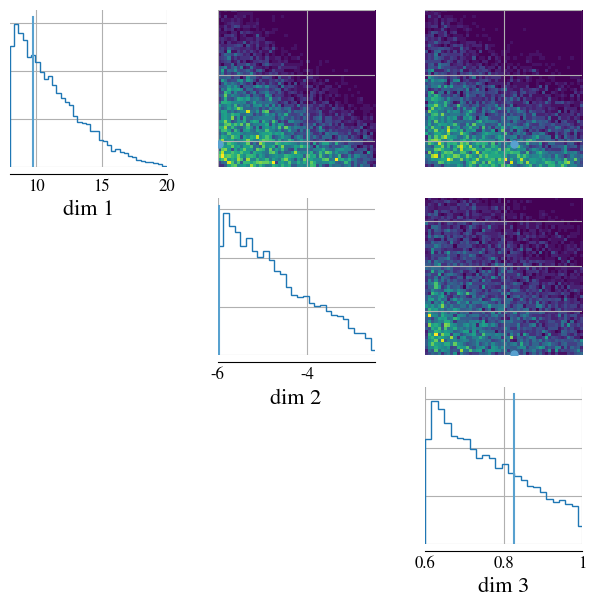

In [92]:
i = 20
with open('artifacts/posterior_mlp_qif_empirical.pkl', 'rb') as f:
        posterior = pickle.load(f)
samples = posterior.sample((10000,), x=GT_mlp[i,3:].astype('float32'))
limits = [[8., 20.]]+[[-6,-2.5]]+[[.6,1.]]
_ = pairplot(
    samples, figsize=(6, 6),
    limits=limits,
    points=GT_mlp[i:i+1,:3]
)

## From data

In [10]:
# Feature extraction moved to scripts/python/features.py so the empirical
# pipeline and the sbi_data training set share one definition.
import jax
import jax.numpy as jnp
from scripts.python.features import get_features_data, get_metrics

n_nodes = 100


In [11]:
# Empirical summary-feature vector for the analysed subject (sub-003):
#   gt_data = [FCD skewness, mean BOLD zero-crossings]
#
# By default we load the anonymised feature vector shipped with the repo, so
# this figure reproduces without access to the raw fMRI. The raw resting-state
# timeseries are available on request (see the README); if present, the block
# below recomputes the same vector from scratch.
FEATURES_FILE = DATA_DIR / 'empirical_features_sub-003.npy'
TS_FILE = (
    'sub-003_ses-V0_task-rest_run-01_space-T1w_desc-AROMA_ROI'
    '_atlas_mask_100Parc_7Net_GS_CSF_WM_gm.npz'
)
raw_fmri = FMRI_DIR / TS_FILE
if raw_fmri.exists():
    ts = np.load(raw_fmri)['fmri']
    fc_stream = get_metrics(ts[:,-100:])
    feats = get_features_data(ts[:,-100:], fc_stream, names_idx, 15, 2)[[5,6]]
    gt_data = feats
else:
    gt_data = np.load(require(FEATURES_FILE))
gt_data


array([ 0.18205132, 98.99      ], dtype=float32)

In [12]:
gt_data

array([ 0.18205132, 98.99      ], dtype=float32)

50513it [00:00, 119016.77it/s]                           
50698it [00:00, 74622.36it/s]                           
/var/folders/vb/l99h97vn0x320_lbt2xvgqjm0000gn/T/ipykernel_72573/1510663129.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


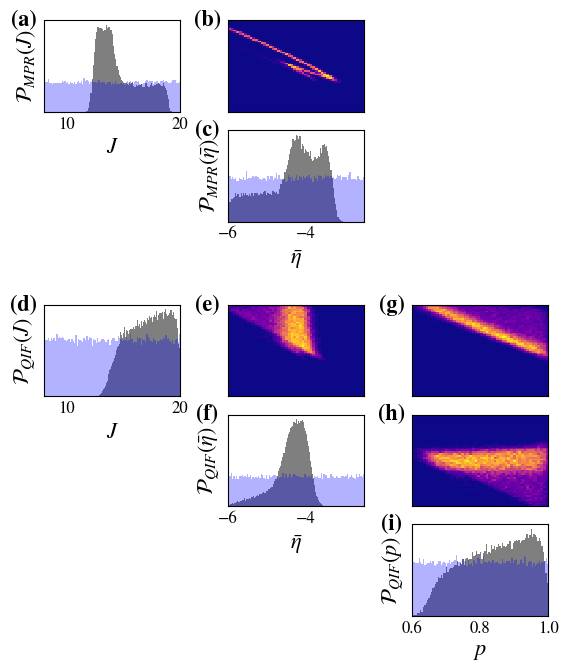

In [25]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=16
matplotlib.rcParams['xtick.labelsize']=12
matplotlib.rcParams['ytick.labelsize']=12
plt.style.use('_mpl-gallery')
networks = np.array([name.split('_')[1] for name in names[:50]])[names_idx[:7]]
fig = plt.figure(constrained_layout=True, figsize=(6,7))
grid = fig.add_gridspec(ncols=1, nrows=2)

subgrid1 = grid[0].subgridspec(3, 3, wspace=.35, hspace=.2)
ax1 = fig.add_subplot(subgrid1[0,0])
ax2 = fig.add_subplot(subgrid1[1,1])
ax3 = fig.add_subplot(subgrid1[0,1])
with open('artifacts/posterior_mpr_empirical.pkl', 'rb') as f:
    post = pickle.load(f)
    
samples = post.sample((50000,), x=gt_data.astype('float32'))
ax1.hist(samples[:,0], color='k', alpha=0.5, histtype='stepfilled', bins=100)
ax2.hist(samples[:,1], color='k', alpha=0.5, histtype='stepfilled', bins=100)
ax3.hist2d(samples[:,1], samples[:,0], bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
[ax.grid(False) for ax in [ax1, ax2, ax3]]
[ax.set_yticks([]) for ax in [ax1, ax2]]
ax3.set_xticks([])
ax3.set_yticks([])
ax1.set_xlim((8,20))
ax2.set_xlim((-6,-2.5))
ax1.set_xlabel(rf'$J$')
ax1.set_ylabel(rf'$\mathcal{{P}}_{{MPR}}({{J}})$')
ax2.set_xlabel(rf'$\bar{{\eta}}$')
ax2.set_ylabel(rf'$\mathcal{{P}}_{{MPR}}({{\bar{{\eta}}}})$')
ax1.annotate('(a)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax3.annotate('(b)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax2.annotate('(c)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ppp = prior.sample((50000,))
[ax.hist(ppp[:,i], color='b', alpha=.3, histtype='stepfilled', bins=100) for i, ax in enumerate([ax1, ax2, ax3])]
[ax.set_yticks([]) for ax in [ax1, ax2]]
[ax.grid(False) for ax in [ax1, ax2]]


subgrid2 = grid[1].subgridspec(3, 3, wspace=.35, hspace=.2)
ax1 = fig.add_subplot(subgrid2[0,0])
ax2 = fig.add_subplot(subgrid2[1,1])
ax3 = fig.add_subplot(subgrid2[2,2])
ax4 = fig.add_subplot(subgrid2[0,1])
ax5 = fig.add_subplot(subgrid2[0,2])
ax6 = fig.add_subplot(subgrid2[1,2])
with open('artifacts/posterior_mlp_qif_empirical.pkl', 'rb') as f:
    post = pickle.load(f)
samples = post.sample((50000,), x=gt_data.astype('float32'))
ax1.hist(samples[:,0], color='k', alpha=0.5, histtype='stepfilled', bins=100)
ax4.hist2d(samples[:,1], samples[:,0], bins=50, cmap='plasma', zorder=0, range=[[-6,-2.5],[8,20]])
ax1.set_xlim((8,20))
ax2.set_xlim((-6,-2.5))
ax4.set_xlim((-6,-2.5))
ax3.set_xlim((.6,1))
ax2.hist(samples[:,1], color='k', alpha=.5, histtype='stepfilled', bins=100)
ax5.hist2d(samples[:,2], samples[:,0], bins=50, cmap='plasma', zorder=0, range=[[.6,1],[8,20]])
ax3.hist(samples[:,2], color='k', alpha=0.5, histtype='stepfilled', bins=100)
ax6.hist2d(samples[:,2], samples[:,1], bins=50, cmap='plasma', zorder=0, range=[[.6,1],[-6,-2.5]])
ax1.set_xlabel(rf'$J$')
ax1.set_ylabel(rf'$\mathcal{{P}}_{{QIF}}({{J}})$')
ax2.set_xlabel(rf'$\bar{{\eta}}$')
ax2.set_ylabel(rf'$\mathcal{{P}}_{{QIF}}({{\bar{{\eta}}}})$')
ax3.set_xlabel(rf'$p$')
ax3.set_ylabel(rf'$\mathcal{{P}}_{{QIF}}({{p}})$')
ax1.annotate('(d)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax4.annotate('(e)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax2.annotate('(f)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax3.annotate('(i)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax5.annotate('(g)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax6.annotate('(h)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
[ax.set_yticks([]) for ax in [ax1, ax2, ax3]]
[ax.set_xticks([]) for ax in [ax4, ax5, ax6]]
[ax.set_yticks([]) for ax in [ax4, ax5, ax6]]
[ax.grid(False) for ax in [ax1, ax2, ax3, ax4, ax5, ax6]]
ppp = prior.sample((50000,))
[ax.hist(ppp[:,i], color='b', alpha=.3, histtype='stepfilled', bins=100) for i, ax in enumerate([ax1, ax2, ax3])]
[ax.set_yticks([]) for ax in [ax1, ax2, ax3]]
[ax.grid(False) for ax in [ax1, ax2, ax3]]

plt.tight_layout()
plt.grid(False)
fig.savefig('./artifacts/inference_data.png', dpi=600, facecolor='None', bbox_inches='tight')
plt.show()
# plt.legend()